## 패키지 로드

In [1]:
# ==================================================
# 사용자 정의 모듈
# ==================================================
from hossam import *


# ==================================================
# 데이터 처리 / 시각화
# ==================================================
import numpy as np
import seaborn as sb
from pandas import DataFrame
from matplotlib import pyplot as plt


# ==================================================
# 머신러닝 파이프라인 / 전처리 / 검증
# ==================================================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
)


# ==================================================
# 성능 평가 지표
# ==================================================
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)


# ==================================================
# 회귀 모델
# ==================================================
from sklearn.linear_model import ElasticNet


In [3]:
origin = load_data("fish_processed")
origin.head()

농어의 길이,높이,두께,무게를 조사한 데이터의 전처리 버전


,길이,높이,두께,무게
0,8.4,2.11,1.41,1.931521
1,13.7,3.53,2.00,3.496508
2,15.0,3.82,2.43,3.713572
3,16.2,4.59,2.63,3.960813
4,17.4,4.59,2.94,4.262680


In [ ]:
df = origin

yname = "무게"

X = df.drop(columns=[yname])
y = df[yname]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=52, 
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((42, 3), (14, 3), (42,), (14,))

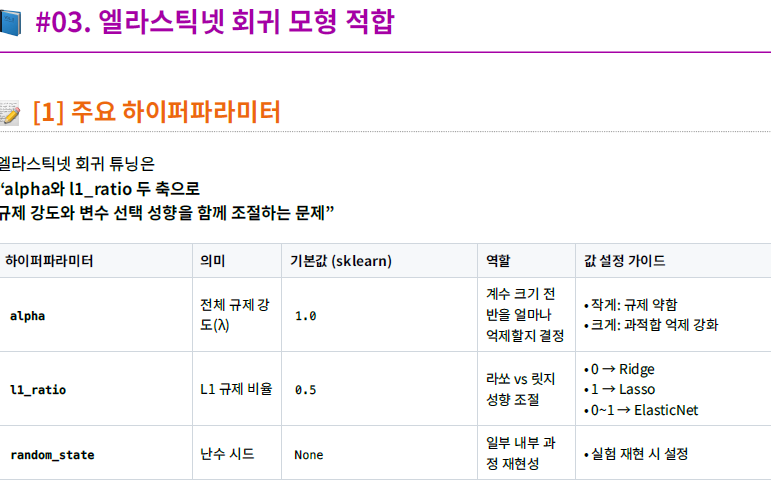<br>
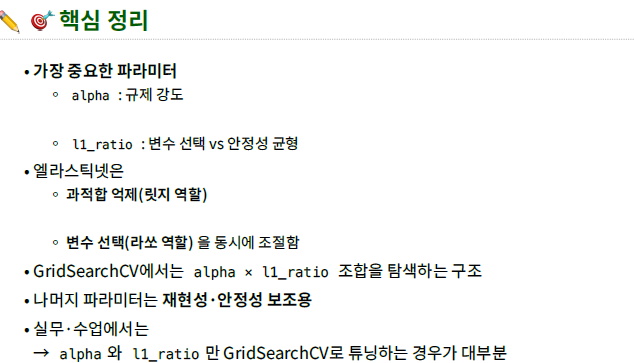

In [6]:
%%time

# ElasticNet 모델 정의 (n_jobs 없음)
pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", ElasticNet(random_state=52)),
    ]
)

# 탐색할 하이퍼파라미터 그리드 설정
param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10],
    "model__l1_ratio": [0.1, 0.5, 0.9],
}

# 그리드 서치 객체 생성
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

# 모델 학습
gs.fit(x_train, y_train)

# 최적 모델
estimator = gs.best_estimator_
estimator


CPU times: total: 0 ns
Wall time: 48.2 μs


NameError: name 'x_train' is not defined

In [9]:
# 예측
y_pred = estimator.predict(x_test)

# 성능 평가 결과 정리
result_df = DataFrame(
    {
        "결정계수(R2)": r2_score(y_test, y_pred),
        "평균절대오차(MAE)": mean_absolute_error(y_test, y_pred),
        "평균제곱오차(MSE)": mean_squared_error(y_test, y_pred),
        "평균오차(RMSE)": np.sqrt(mean_squared_error(y_test, y_pred)),
        "평균 절대 백분오차 비율(MAPE)": mean_absolute_percentage_error(
            y_test, y_pred
        ),
        "평균 비율 오차(MPE)": np.mean((y_test - y_pred) / y_test * 100),
    },
    index=["성능지표"],
)

display(result_df)


NameError: name 'estimator' is not defined

## 과적합 여부 확인

In [11]:
# =========================================
# 과적합 여부 확인
# 반드시 원본 데이터 적용
# =========================================

train_sizes, train_scores, cv_scores = learning_curve(
    estimator=estimator,
    X=x,
    y=y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8),
    shuffle=True,
    random_state=52,
    n_jobs=-1,
)

# neg RMSE → RMSE
train_rmse = -train_scores
cv_rmse = -cv_scores

# 평균 / 표준편차
train_mean = train_rmse.mean(axis=1)
cv_mean = cv_rmse.mean(axis=1)
cv_std = cv_rmse.std(axis=1)

# 마지막 구간 값
final_train = train_mean[-1]
final_cv = cv_mean[-1]
final_std = cv_std[-1]

gap_ratio = final_train / final_cv
var_ratio = final_std / final_cv

# =========================================
# 과소적합 기준 (some_threshold)
# =========================================

# 기준모델 RMSE (평균 예측)
y_mean = y.mean()
rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

# 분산 기반
std_y = y.std()

# 최소 설명력(R²) 기반
min_r2 = 0.10
rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

# 최종 threshold (가장 관대한 기준)
some_threshold = min(rmse_naive, std_y, rmse_r2)

# =========================================
# 판정 로직
# =========================================

if gap_ratio > 0.95 and final_cv > some_threshold:
    status = "⚠ 과소적합 (bias 큼)"
elif gap_ratio < 0.8:
    status = "⚠ 과대적합 (variance 큼)"
elif gap_ratio <= 0.95 and var_ratio <= 0.10:
    status = "✅ 일반화 양호"
elif var_ratio > 0.15:
    status = "⚠ 데이터 부족 / 분산 큼"
else:
    status = "⚠ 판단모호"

# =========================================
# 정량 결과표
# =========================================

result_df = DataFrame(
    {
        "지표": [
            "Train RMSE",
            "CV RMSE 평균",
            "CV RMSE 표준편차",
            "Train/CV 비율",
            "CV 변동성 비율",
            "판정 결과",
        ],
        "값": [
            final_train,
            final_cv,
            final_std,
            gap_ratio,
            var_ratio,
            status,
        ],
    }
)

result_df


NameError: name 'estimator' is not defined

## 학습곡선

NameError: name 'train_sizes' is not defined

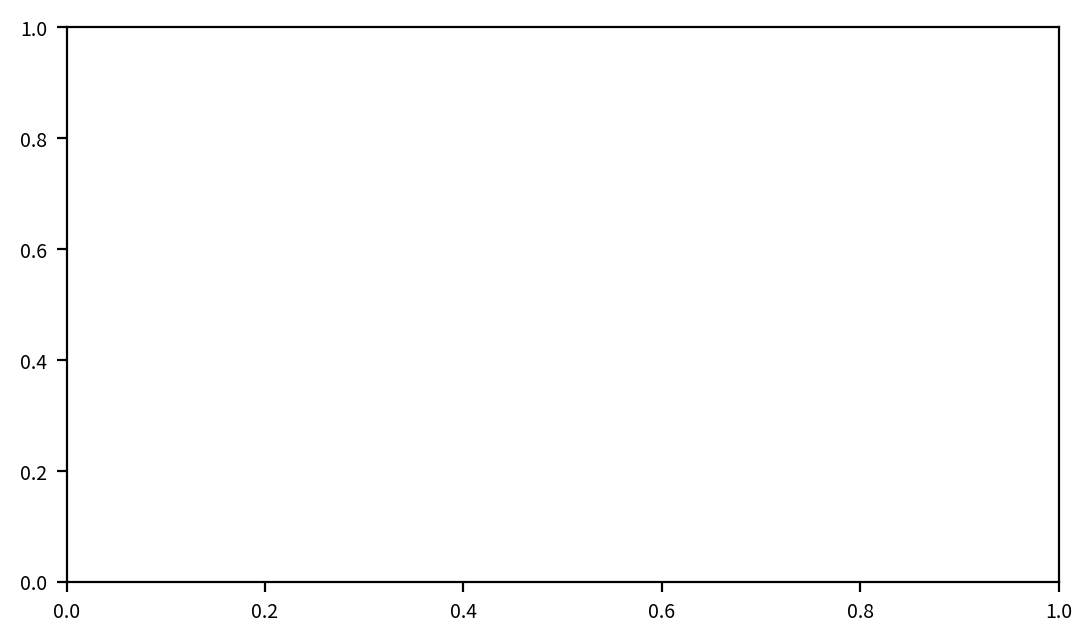

In [14]:
figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

# Train RMSE
sb.lineplot(
    x=train_sizes,
    y=train_mean,
    marker="o",
    label="Train RMSE",
    ax=ax,
)

# CV RMSE
sb.lineplot(
    x=train_sizes,
    y=cv_mean,
    marker="o",
    label="CV RMSE",
    ax=ax,
)

ax.set_title("Learning Curve (RMSE 기준)", fontsize=12, pad=8)
ax.set_xlabel("훈련 데이터 수", fontsize=9)
ax.set_ylabel("RMSE", fontsize=9)

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
plt.close()



Pipeline<br>
StandardScaler<br>
ElasticNet<br>
r2_score, MAE, MSE, MAPE


randomestate=52로 지정한 이유<br>
shape로 훈련,검증 데이터 분리